In [113]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest

In [114]:
np.random.seed(2137)

def generate_network_data(n_normal=950, n_anomaly=50):
    normal = np.vstack([
        np.random.randn(n_normal // 3, 4) * 0.5 + [50, 100, 0.8, 30],
        np.random.randn(n_normal // 3, 4) * 0.5 + [55, 110, 0.75, 35],
        np.random.randn(n_normal // 3, 4) * 0.5 + [48, 95, 0.85, 28],
    ])
    anomalies = np.vstack([
        np.random.randn(n_anomaly // 2, 4) * 0.3 + [200, 500, 0.1, 5], 
        np.random.randn(n_anomaly // 2, 4) * 0.3 + [10, 10, 0.99, 100],
    ])
    X = np.vstack([normal, anomalies])
    y = np.array([0] * len(normal) + [1] * len(anomalies))
    return X, y

In [115]:
def c_factor(n):
    """Oblicza oczekiwana głębokośc BST dla n elementów."""
    if n <= 1:
        return 0
    return 2 * (np.log(n - 1) + 0.5772156649) - 2 * (n - 1) / n

def anomaly_score(path_lengths, n_samples):
    """ Oblicza znormalizowany anomaly score ."""
    c = c_factor(n_samples)
    return 2 ** (-np.array(path_lengths) / c)

In [116]:
class IsolationTree:
    def __init__(self, max_depth=None):
        self.max_depth = max_depth
        self.root = None

    def fit(self, X, current_depth=0):
        n_samples, n_features = X.shape
        
        if n_samples <= 1 or (self.max_depth and current_depth >= self.max_depth):
            return {
                'type': 'leaf', 
                'size': n_samples, 
                'depth': current_depth,
                'data_indices': np.arange(n_samples) 
            }
        
        feature = np.random.randint(0, n_features)
        
        min_val, max_val = X[:, feature].min(), X[:, feature].max()
        
        if min_val == max_val:
             return {'type': 'leaf', 'size': n_samples, 'depth': current_depth}

        threshold = np.random.uniform(min_val, max_val)
        
        left_mask = X[:, feature] < threshold
        right_mask = ~left_mask
        
        return {
            'type': 'node',
            'feature': feature,
            'threshold': threshold,
            'left': self.fit(X[left_mask], current_depth + 1),
            'right': self.fit(X[right_mask], current_depth + 1)
        }

    def train(self, X):
        if self.max_depth is None:
            self.max_depth = int(np.ceil(np.log2(len(X))))
        self.root = self.fit(X, 0)
        return self

    def path_length(self, x, node, current_depth=0):
        """Oblicza glebokosc izolacji punktu x."""
        if node['type'] == 'leaf':
            return current_depth
        
        if x[node['feature']] < node['threshold']:
            return self.path_length(x, node['left'], current_depth + 1)
        else:
            return self.path_length(x, node['right'], current_depth + 1)
            
    def predict_single(self, x):
        return self.path_length(x, self.root)

A

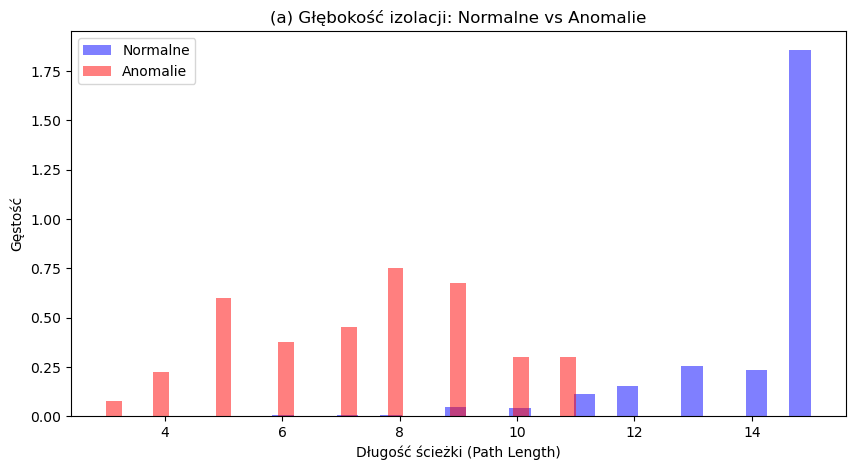

In [117]:
X, y = generate_network_data()

iso_tree = IsolationTree(max_depth=15)
iso_tree.train(X)

depths_normal = []
depths_anomaly = []

for i in range(len(X)):
    d = iso_tree.predict_single(X[i])
    if y[i] == 0:
        depths_normal.append(d)
    else:
        depths_anomaly.append(d)

plt.figure(figsize=(10, 5))
plt.hist(depths_normal, bins=30, alpha=0.5, label='Normalne', density=True, color='blue')
plt.hist(depths_anomaly, bins=30, alpha=0.5, label='Anomalie', density=True, color='red')
plt.title("(a) Głębokość izolacji: Normalne vs Anomalie")
plt.xlabel("Długość ścieżki (Path Length)")
plt.ylabel("Gęstość")
plt.legend()
plt.show()

B

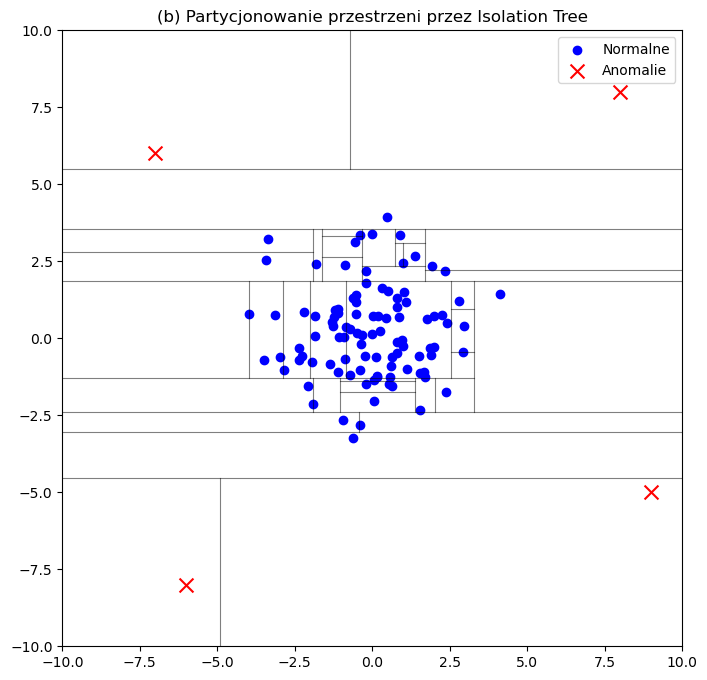

In [118]:
X_2d_normal = np.random.randn(100, 2) * 1.5
X_2d_outliers = np.array([[8, 8], [-7, 6], [9, -5], [-6, -8]]) 
X_2d = np.vstack([X_2d_normal, X_2d_outliers])

viz_tree = IsolationTree(max_depth=10)
viz_tree.train(X_2d)

def plot_partition(node, x_min, x_max, y_min, y_max, depth=0):
    if node['type'] == 'leaf':
        return

    feature = node['feature']
    threshold = node['threshold']
    
    if feature == 0: # Podział pionowy (oś X)
        plt.plot([threshold, threshold], [y_min, y_max], 'k-', linewidth=0.8, alpha=0.5)
        plot_partition(node['left'], x_min, threshold, y_min, y_max, depth+1)
        plot_partition(node['right'], threshold, x_max, y_min, y_max, depth+1)
    else: # Podział poziomy (oś Y)
        plt.plot([x_min, x_max], [threshold, threshold], 'k-', linewidth=0.8, alpha=0.5)
        plot_partition(node['left'], x_min, x_max, y_min, threshold, depth+1)
        plot_partition(node['right'], x_min, x_max, threshold, y_max, depth+1)

plt.figure(figsize=(8, 8))
plt.scatter(X_2d_normal[:, 0], X_2d_normal[:, 1], c='blue', label='Normalne')
plt.scatter(X_2d_outliers[:, 0], X_2d_outliers[:, 1], c='red', s=100, marker='x', label='Anomalie')
plt.xlim(-10, 10)
plt.ylim(-10, 10)

plot_partition(viz_tree.root, -10, 10, -10, 10)
plt.title("(b) Partycjonowanie przestrzeni przez Isolation Tree")
plt.legend()
plt.show()

Intuicyjnie: Jak jest dużo przestrzeni to łatwiej odrogodzić punkt od reszty, większe pstwo na trafienie w taki podział, który efektywnie dzieli punkt z małą liczbą sąsiadów od reszty

C

In [119]:
class MyIsolationForest:
    def __init__(self, n_estimators=100, max_samples=256):
        self.n_estimators = n_estimators
        self.max_samples = max_samples
        self.trees = []
    
    def fit(self, X):
        """Trenuje 100 drzew na losowych podpróbkach."""
        self.trees = []
        n_samples = len(X)
        
        sample_size = min(n_samples, self.max_samples)
        
        for _ in range(self.n_estimators):
            indices = np.random.choice(n_samples, sample_size, replace=False)
            X_sample = X[indices]
            
            max_depth = int(np.ceil(np.log2(sample_size)))
            tree = IsolationTree(max_depth=max_depth)
            tree.train(X_sample)
            
            self.trees.append(tree)
        return self

    def compute_paths(self, X):
        """Zwraca średnią długość ścieżki E[h(x)] dla każdego punktu."""
        all_paths = np.zeros((len(X), self.n_estimators))
        
        for i, tree in enumerate(self.trees):
            all_paths[:, i] = np.array([tree.predict_single(x) for x in X])
            
        return np.mean(all_paths, axis=1)
    
    def anomaly_score(self, X):
        """Oblicza ostateczny Anomaly Score s(x, n)."""
        avg_path_lengths = self.compute_paths(X)
        
        c = c_factor(self.max_samples)
        
        scores = 2 ** (-avg_path_lengths / c)
        
        return scores

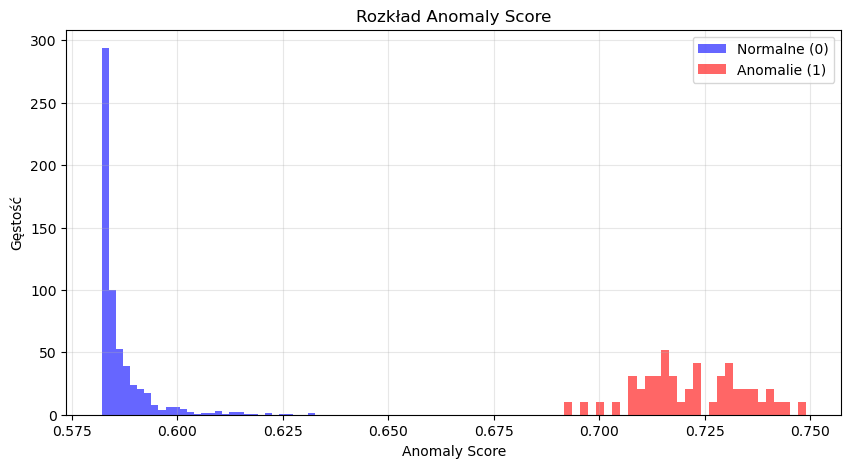

In [120]:
iso_forest = MyIsolationForest(n_estimators=100, max_samples=256)
iso_forest.fit(X)
scores = iso_forest.anomaly_score(X)

plt.figure(figsize=(10, 5))
plt.hist(scores[y==0], bins=30, alpha=0.6, label='Normalne (0)', color='blue', density=True)
plt.hist(scores[y==1], bins=30, alpha=0.6, label='Anomalie (1)', color='red', density=True)
plt.title("Rozkład Anomaly Score")
plt.xlabel("Anomaly Score")
plt.ylabel("Gęstość")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [121]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2137)

results_metrics = {}

In [122]:
my_if = MyIsolationForest(n_estimators=100, max_samples=256)
my_if.fit(X_train)

scores_my = my_if.anomaly_score(X_test)

threshold = 0.65
y_pred_my = (scores_my > threshold).astype(int)

print(f"\n[MyIsolationForest] (Threshold={threshold}) ")
print(classification_report(y_test, y_pred_my, target_names=['Normal', 'Anomaly']))

results_metrics['MyIF'] = f1_score(y_test, y_pred_my)


[MyIsolationForest] (Threshold=0.65) 
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       279
     Anomaly       1.00      1.00      1.00        21

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [123]:
lof = LocalOutlierFactor(n_neighbors=20, novelty=True)
lof.fit(X_train)

# LOF zwraca: 1 (ok), -1 (anomaly)
y_pred_lof_raw = lof.predict(X_test)
# Mapowanie: 1 -> 0, -1 -> 1
y_pred_lof = np.where(y_pred_lof_raw == 1, 0, 1)

print("\n[Local Outlier Factor]")
print(classification_report(y_test, y_pred_lof, target_names=['Normal', 'Anomaly']))
results_metrics['LOF'] = f1_score(y_test, y_pred_lof)


[Local Outlier Factor]
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99       279
     Anomaly       0.78      1.00      0.88        21

    accuracy                           0.98       300
   macro avg       0.89      0.99      0.93       300
weighted avg       0.98      0.98      0.98       300



In [124]:
oc_svm = OneClassSVM(kernel='rbf', nu=0.05, gamma='scale')
oc_svm.fit(X_train)

y_pred_svm_raw = oc_svm.predict(X_test)
y_pred_svm = np.where(y_pred_svm_raw == 1, 0, 1)

print("\n[One-Class SVM]")
print(classification_report(y_test, y_pred_svm, target_names=['Normal', 'Anomaly']))
results_metrics['OCSVM'] = f1_score(y_test, y_pred_svm)


[One-Class SVM]
              precision    recall  f1-score   support

      Normal       0.95      0.98      0.96       279
     Anomaly       0.55      0.29      0.38        21

    accuracy                           0.93       300
   macro avg       0.75      0.63      0.67       300
weighted avg       0.92      0.93      0.92       300



In [125]:
print("\nBadanie wpływu parametrów")

n_estimators_opts = [50, 100, 200]
max_samples_opts = [64, 128, 256]

auc_matrix = np.zeros((len(n_estimators_opts), len(max_samples_opts)))

print(f"{'Trees':<6} | {'Samples':<8} | {'ROC AUC':<8}")
print("-" * 30)

for i, n_trees in enumerate(n_estimators_opts):
    for j, n_samples in enumerate(max_samples_opts):
        
        model = MyIsolationForest(n_estimators=n_trees, max_samples=n_samples)
        model.fit(X_train)
        
        scores = model.anomaly_score(X_test)
        auc = roc_auc_score(y_test, scores)
        
        auc_matrix[i, j] = auc
        print(f"{n_trees:<6} | {n_samples:<8} | {auc:.4f}")


Badanie wpływu parametrów
Trees  | Samples  | ROC AUC 
------------------------------
50     | 64       | 1.0000
50     | 128      | 1.0000
50     | 256      | 1.0000
100    | 64       | 1.0000
100    | 128      | 1.0000
100    | 256      | 1.0000
200    | 64       | 1.0000
200    | 128      | 1.0000
200    | 256      | 1.0000


Wszystko radzi sobie perfekcyjnie, dziwne

In [127]:
print("\n=Porównanie ze Sklearn IsolationForest")

# automatycznie ustala próg na podstawie parametru 'contamination'
sk_if = IsolationForest(n_estimators=100, max_samples=256, contamination='auto', random_state=2137)
sk_if.fit(X_train)

y_pred_sk_raw = sk_if.predict(X_test)
y_pred_sk = np.where(y_pred_sk_raw == 1, 0, 1)

# tutaj jest odwrotnie (z minusem)
scores_sk = -sk_if.decision_function(X_test)

print("\n[Sklearn IsolationForest]")
print(classification_report(y_test, y_pred_sk, target_names=['Normal', 'Anomaly']))

auc_my = roc_auc_score(y_test, scores_my)
auc_sk = roc_auc_score(y_test, scores_sk)

print(f"ROC AUC Nasz:    {auc_my:.4f}")
print(f"ROC AUC Sklearn: {auc_sk:.4f}")


=Porównanie ze Sklearn IsolationForest

[Sklearn IsolationForest]
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99       279
     Anomaly       0.75      1.00      0.86        21

    accuracy                           0.98       300
   macro avg       0.88      0.99      0.92       300
weighted avg       0.98      0.98      0.98       300

ROC AUC Nasz:    1.0000
ROC AUC Sklearn: 1.0000


Wszystko śmiga bez zarzutów, aż dziwne